In [1]:
# 01. EDA for Peptide Sequencing
import pandas as pd
from pyteomics import mzml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../figures/eda', exist_ok=True)


/Users/akshaymohanrevankar/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-1drjc7h4 because there was an issue with the default path (/Users/akshaymohanrevankar/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Configuration
MZML_PATH = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Ecoli_EV_1.mzML"
XLSX_PATH = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Database search output_Ecoli_EV_1.xlsx"


In [3]:
# 1. Load Data
df = pd.read_excel(XLSX_PATH)
df = df.dropna(subset=['Sequence', 'Scan number'])

print(f"Total labeled peptides loaded: {len(df)}")
df.head()


Total labeled peptides loaded: 1495


,Scan number,Scan index,Sequence,Length,Missed cleavages,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score diffs,Acetyl (Protein N-term),...,Mass deviations [ppm],Masses,Number of matches,Intensity coverage,Peak coverage,Unfragmented precursor intensity,Unfragmented precursor fraction,Neutral loss level,ETD identification type,Contaminant
0,1636,114,CKPTSPGR,8,0,Unmodified,_CKPTSPGR_,NaN,NaN,0,...,-2.3287508098677687;0.17296926689536715;-2.015...,175.1193599903514;329.1931228163069;416.226047...,10,0.298558,0.181818,0,0,NaN,Unknown,NaN
1,1664,118,SHALNATK,8,0,Unmodified,_SHALNATK_,NaN,NaN,0,...,0.007566548729029053;-1.0571338544715363;-1.10...,147.1128030574638;248.16074498382486;319.19794...,22,0.424014,0.203704,0,0,NaN,Unknown,NaN
2,1720,134,SFSHQAGASSK,11,0,Unmodified,_SFSHQAGASSK_,NaN,NaN,0,...,-0.043783658882078476;-0.8289604569218284;-1.7...,147.1128106117371;234.14502667746828;321.17742...,24,0.386609,0.206897,0,0,NaN,Unknown,NaN
3,1738,139,NKPGVYTK,8,0,Unmodified,_NKPGVYTK_,NaN,NaN,0,...,-0.1678653095268745;-0.943679803864639;-0.6649...,147.11282886574054;248.16071682895657;411.2240...,17,0.239815,0.109677,0,0,NaN,Unknown,+
4,1740,141,SHALNATK,8,0,Unmodified,_SHALNATK_,NaN,NaN,0,...,-0.3861867643440702;-0.49710206749090574;-1.43...,147.11286098363976;248.1606060058503;319.19805...,20,0.528098,0.250000,0,0,NaN,Unknown,NaN


In [4]:
# 2. Extract Data from mzML
peaks_counts = []
precursor_mzs = []
charge_states = []
spectra_dict = {}

count = 0
with mzml.read(MZML_PATH) as reader:
    for spectrum in reader:
        # Match scan number with df
        scan_match = re.search(r'scan=(\d+)', spectrum['id'])
        if scan_match:
            scan_num = int(scan_match.group(1))
            
            # Save up to 5000 spectra for EDA that are in labels
            if scan_num in df['Scan number'].values:
                mzs = spectrum.get('m/z array', [])
                ints = spectrum.get('intensity array', [])
                
                peaks_counts.append(len(mzs))
                
                prec_mz = None
                charge = None
                
                for p in spectrum.get('precursorList', {}).get('precursor', []):
                    for ion in p.get('selectedIonList', {}).get('selectedIon', []):
                        prec_mz = ion.get('selected ion m/z')
                        charge = ion.get('charge state')
                
                if prec_mz is not None: precursor_mzs.append(prec_mz)
                if charge is not None: charge_states.append(charge)
                
                spectra_dict[scan_num] = {'mzs': mzs, 'ints': ints, 'charge': charge, 'prec_mz': prec_mz}
                count += 1
                
                if count >= 5000:
                    break

print(f"Number of labeled spectra matched and loaded: {count}")


Number of labeled spectra matched and loaded: 1488


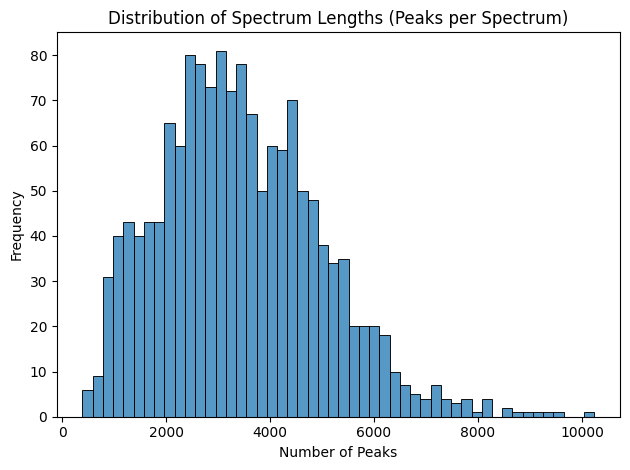

In [5]:
# 3. Distribution of peaks per spectrum
plt.figure()
sns.histplot(peaks_counts, bins=50)
plt.title("Distribution of Spectrum Lengths (Peaks per Spectrum)")
plt.xlabel("Number of Peaks")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig('../figures/eda/peaks_distribution.png')
plt.show()


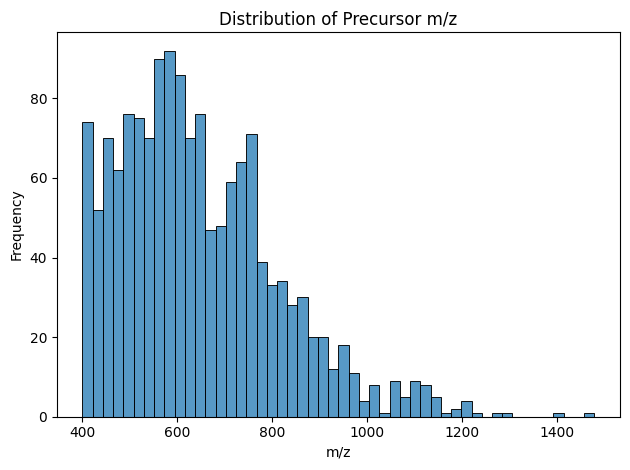

In [6]:
# 4. Distribution of precursor m/z values
plt.figure()
sns.histplot(precursor_mzs, bins=50)
plt.title("Distribution of Precursor m/z")
plt.xlabel("m/z")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig('../figures/eda/precursor_mz_dist.png')
plt.show()


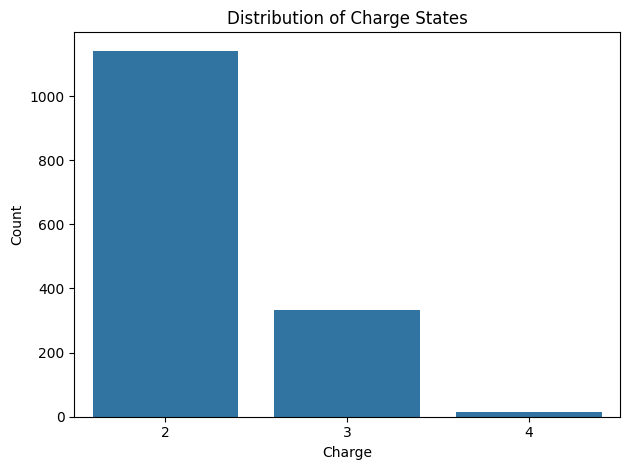

In [7]:
# 5. Distribution of charge states
plt.figure()
sns.countplot(x=charge_states)
plt.title("Distribution of Charge States")
plt.xlabel("Charge")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('../figures/eda/charge_dist.png')
plt.show()


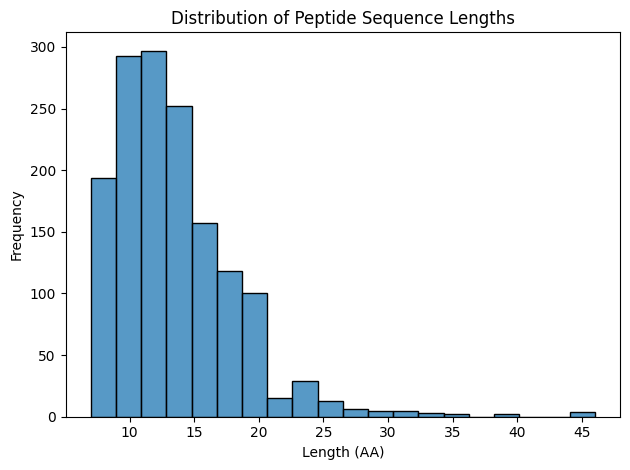

In [8]:
# 6. Distribution of peptide sequence lengths
df['seq_len'] = df['Sequence'].apply(len)
plt.figure()
sns.histplot(df['seq_len'], bins=20)
plt.title("Distribution of Peptide Sequence Lengths")
plt.xlabel("Length (AA)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig('../figures/eda/seq_length_dist.png')
plt.show()


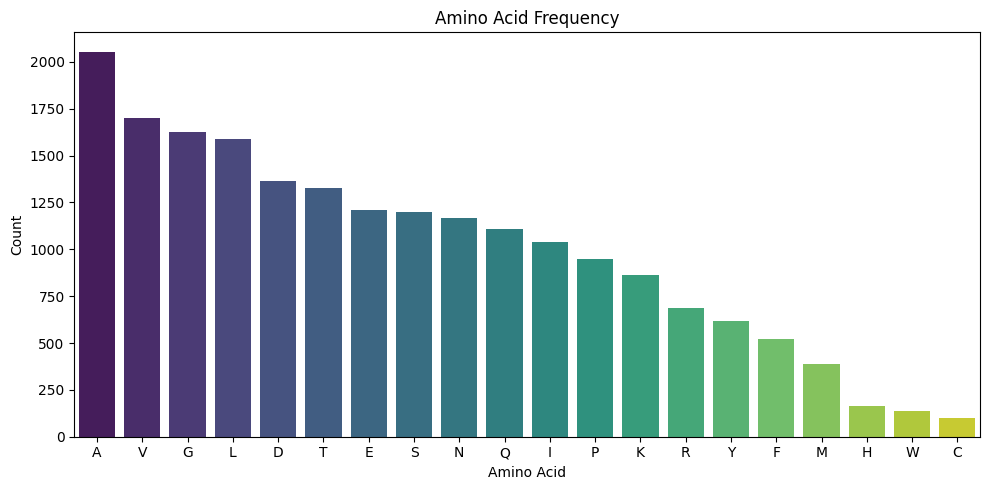

In [9]:
# 7. Amino acid frequency bar chart
import collections
aa_counter = collections.Counter("".join(df['Sequence']))
aa_df = pd.DataFrame.from_dict(aa_counter, orient='index').reset_index()
aa_df.columns = ['Amino Acid', 'Count']
aa_df = aa_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=aa_df, x='Amino Acid', y='Count', palette='viridis')
plt.title("Amino Acid Frequency")
plt.xlabel("Amino Acid")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('../figures/eda/amino_acid_freq.png')
plt.show()


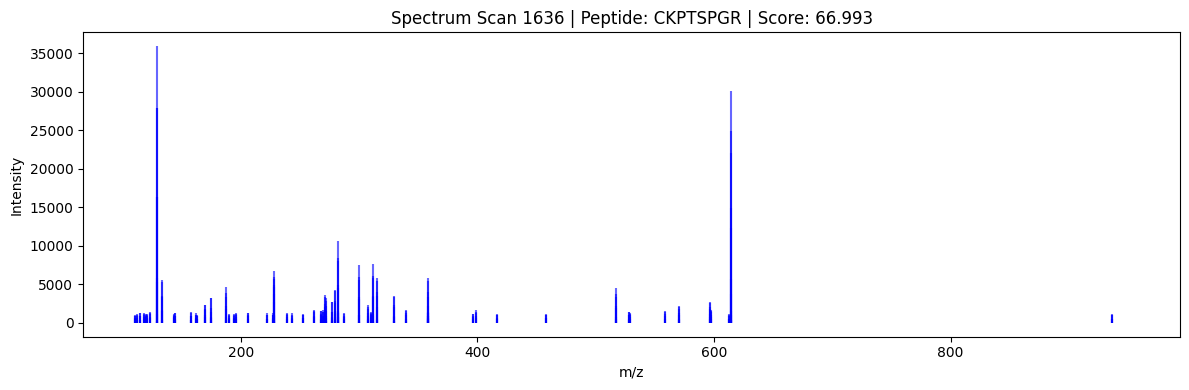

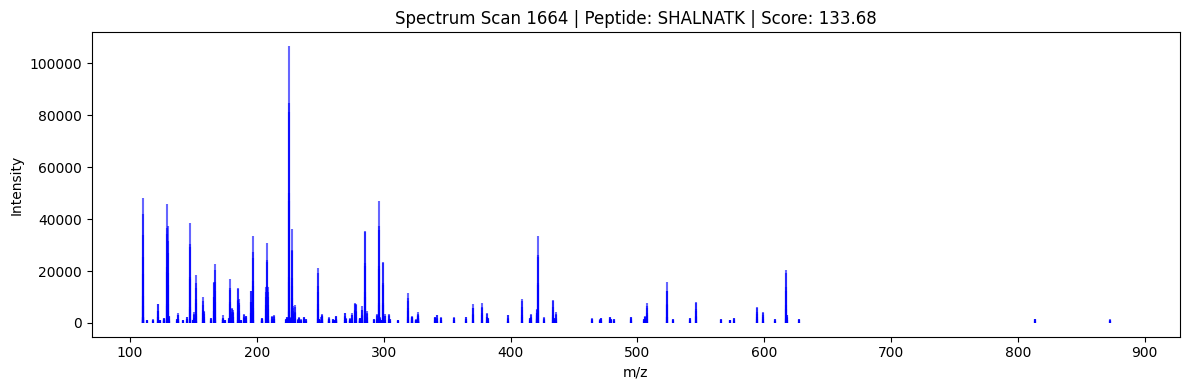

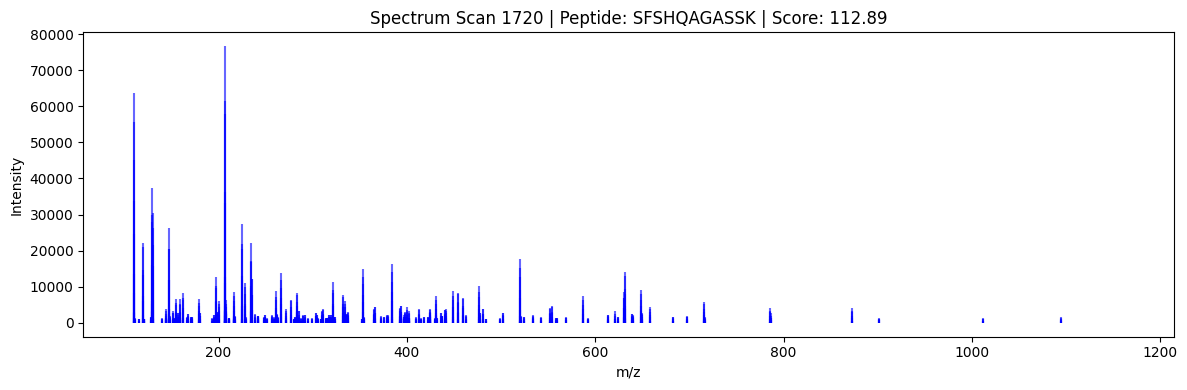

In [10]:
# 8. Plot 3 example spectra
sample_scans = list(spectra_dict.keys())[:3]

for scan in sample_scans:
    spec = spectra_dict[scan]
    seq = df[df['Scan number'] == scan]['Sequence'].values[0]
    score = df[df['Scan number'] == scan]['Score'].values[0] if 'Score' in df.columns else 'N/A'
    
    plt.figure(figsize=(12, 4))
    plt.vlines(spec['mzs'], 0, spec['ints'], color='b', alpha=0.6)
    plt.title(f"Spectrum Scan {scan} | Peptide: {seq} | Score: {score}")
    plt.xlabel('m/z')
    plt.ylabel('Intensity')
    plt.tight_layout()
    plt.savefig(f'../figures/eda/spectrum_{scan}.png')
    plt.show()


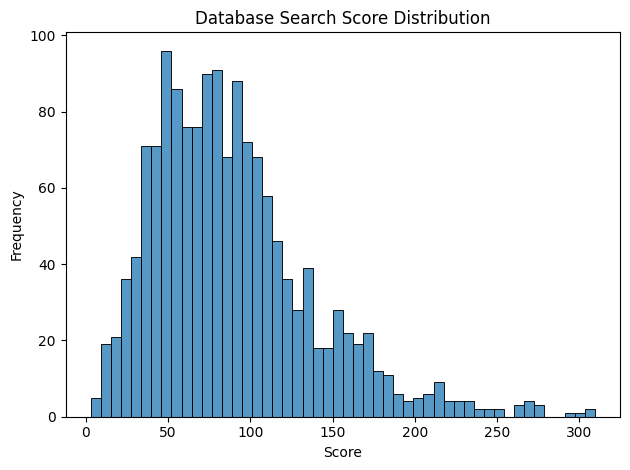

In [11]:
# 9. Score distribution
if 'Score' in df.columns:
    scores = pd.to_numeric(df['Score'], errors='coerce').dropna()
    plt.figure()
    sns.histplot(scores, bins=50)
    plt.title("Database Search Score Distribution")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig('../figures/eda/score_dist.png')
    plt.show()


In [12]:
# 10. Summary stats table
summary_stats = pd.DataFrame({
    'Metric': ['Total Peptides', 'Unique Peptides', 'Avg Peaks/Spectrum', 'Avg Precursor m/z', 'Avg Peptide Length'],
    'Value': [
        len(df),
        df['Sequence'].nunique(),
        np.mean(peaks_counts) if peaks_counts else 0,
        np.mean(precursor_mzs) if precursor_mzs else 0,
        df['seq_len'].mean()
    ]
})
summary_stats


,Metric,Value
0,Total Peptides,1495.000000
1,Unique Peptides,793.000000
2,Avg Peaks/Spectrum,3435.622312
3,Avg Precursor m/z,646.923869
4,Avg Peptide Length,13.254181
